In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data=pd.read_csv("Datasets\Mumbai House Prices.csv")
data.head()

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New


In [18]:
data.shape

(76038, 9)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


In [20]:
data.describe(include='all')

,bhk,type,locality,area,price,price_unit,region,status,age
count,76038.000000,76038,76038,76038.000000,76038.00000,76038,76038,76038,76038
unique,NaN,5,9782,NaN,NaN,2,228,2,3
top,NaN,Apartment,Hiranandani Meadows,NaN,NaN,Cr,Thane West,Ready to move,New
freq,NaN,74854,861,NaN,NaN,40981,14868,44982,38072
mean,2.015111,NaN,NaN,1024.536850,29.38227,NaN,NaN,NaN,NaN
std,0.922754,NaN,NaN,670.276165,32.90345,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,127.000000,1.00000,NaN,NaN,NaN,NaN
25%,1.000000,NaN,NaN,640.000000,1.75000,NaN,NaN,NaN,NaN
50%,2.000000,NaN,NaN,872.000000,5.50000,NaN,NaN,NaN,NaN
75%,3.000000,NaN,NaN,1179.000000,59.00000,NaN,NaN,NaN,NaN


In [21]:
data['price_lakh']=data.apply(lambda y:y['price']*100 if y['price_unit']=='Cr' else y['price'],axis=1)

In [22]:
data.drop('price_unit',axis=1,inplace=True)
data.drop('price',axis=1,inplace=True)
data.describe(include='all')

,bhk,type,locality,area,region,status,age,price_lakh
count,76038.000000,76038,76038,76038.000000,76038,76038,76038,76038.000000
unique,NaN,5,9782,NaN,228,2,3,NaN
top,NaN,Apartment,Hiranandani Meadows,NaN,Thane West,Ready to move,New,NaN
freq,NaN,74854,861,NaN,14868,44982,38072,NaN
mean,2.015111,NaN,NaN,1024.536850,NaN,NaN,NaN,168.417795
std,0.922754,NaN,NaN,670.276165,NaN,NaN,NaN,217.665511
min,1.000000,NaN,NaN,127.000000,NaN,NaN,NaN,4.490000
25%,1.000000,NaN,NaN,640.000000,NaN,NaN,NaN,64.000000
50%,2.000000,NaN,NaN,872.000000,NaN,NaN,NaN,110.000000
75%,3.000000,NaN,NaN,1179.000000,NaN,NaN,NaN,194.000000


In [23]:
data.head(10)

,bhk,type,locality,area,region,status,age,price_lakh
0,3,Apartment,Lak And Hanware The Residency Tower,685,Andheri West,Ready to move,New,250.00
1,2,Apartment,Radheya Sai Enclave Building No 2,640,Naigaon East,Under Construction,New,52.51
2,2,Apartment,Romell Serene,610,Borivali West,Under Construction,New,173.00
3,2,Apartment,Soundlines Codename Urban Rainforest,876,Panvel,Under Construction,New,59.98
4,2,Apartment,Origin Oriana,659,Mira Road East,Under Construction,New,94.11
5,2,Apartment,Bhoomi Simana Wing A Phase 1,826,Parel,Under Construction,New,330.00
6,5,Villa,Agami Estancia,2921,Boisar,Under Construction,New,199.00
7,3,Apartment,Sanghvi Infenia,778,Santacruz East,Under Construction,New,289.00
8,1,Apartment,Shubh Shreeji Heights,396,Badlapur East,Ready to move,New,29.84
9,2,Apartment,Aplite Greenstone Heritage,671,Fort,Under Construction,New,272.00


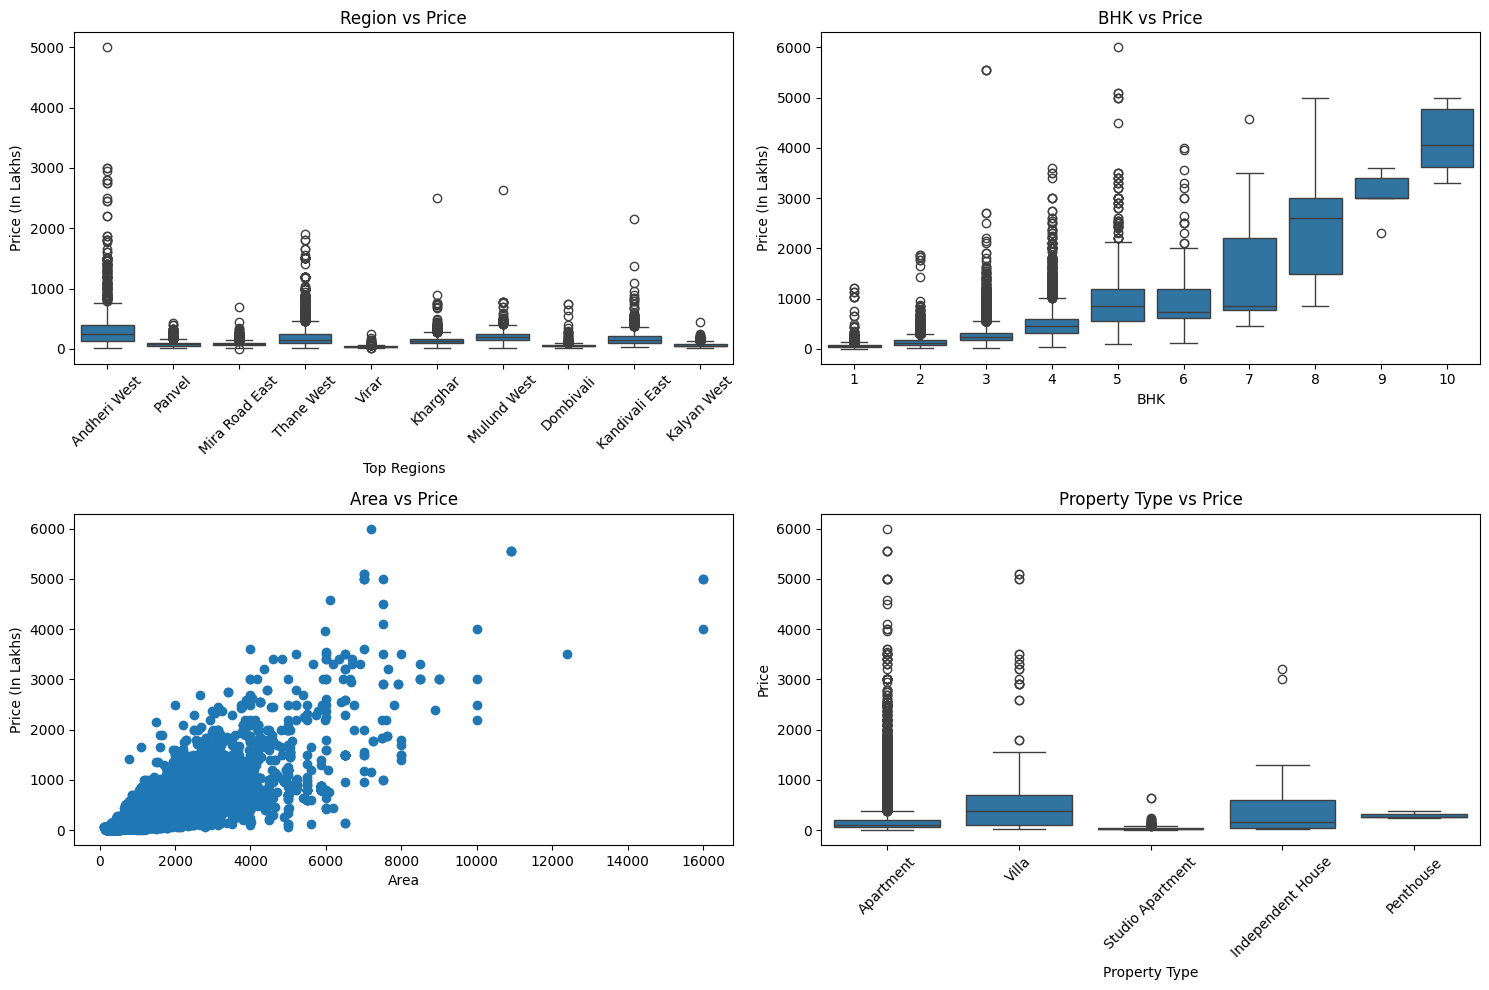

In [24]:
fig=plt.figure(figsize=(15,10))

f1=fig.add_subplot(2,2,1)
top_regions = data['region'].value_counts().head(10).index
sns.boxplot(x='region', y='price_lakh', data=data[data['region'].isin(top_regions)],ax=f1)
f1.set_title("Region vs Price")
f1.set_xlabel("Top Regions")
f1.tick_params(axis='x',rotation=45)
f1.set_ylabel("Price (In Lakhs)")

f2=fig.add_subplot(2,2,2)
sns.boxplot(x='bhk',y='price_lakh',data=data,ax=f2)
f2.set_title("BHK vs Price")
f2.set_xlabel("BHK")
f2.set_ylabel("Price (In Lakhs)")

f3=fig.add_subplot(2,2,3)
f3.scatter(data['area'],data['price_lakh'])
f3.set_title("Area vs Price")
f3.set_xlabel("Area")
f3.set_ylabel("Price (In Lakhs)")

f4=fig.add_subplot(2,2,4)
sns.boxplot(x='type',y='price_lakh',data=data,ax=f4)
f4.set_title("Property Type vs Price")
f4.set_xlabel("Property Type")
f4.set_ylabel("Price")
f4.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

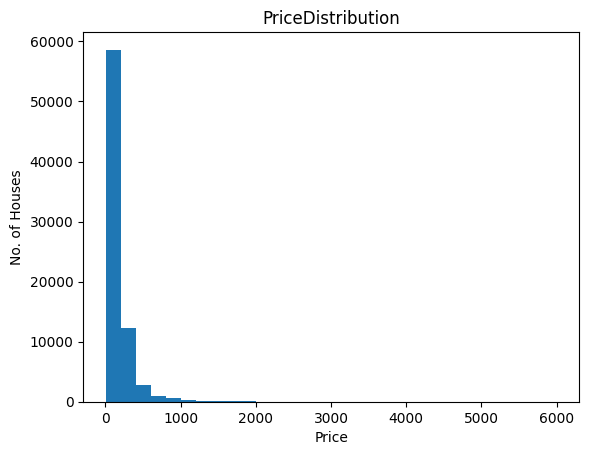

In [25]:
plt.hist(data['price_lakh'],bins=30)
plt.title("PriceDistribution")
plt.xlabel("Price")
plt.ylabel("No. of Houses")
plt.show()

In [26]:
data['region'].value_counts()

region
Thane West         14868
Mira Road East      9902
Dombivali           3041
Kandivali East      2568
Kharghar            2362
                   ...  
Police Colony          1
GTB Nagar              1
Bandra                 1
Sector 14 Vashi        1
Goregaon               1
Name: count, Length: 228, dtype: int64

In [27]:
data.dtypes

bhk             int64
type           object
locality       object
area            int64
region         object
status         object
age            object
price_lakh    float64
dtype: object

In [28]:
# Frequency Encoding -> TO handle high cardinality Columns (locality,region)
data['locality_freq']=data['locality'].map(data['locality'].value_counts())
data['region_freq']=data['region'].map(data['region'].value_counts())

data=data.drop(['locality','region'],axis=1)

# one hot encoding for others
data=pd.get_dummies(data,columns=['type','status','age'],drop_first=True)
data.head()

,bhk,area,price_lakh,locality_freq,region_freq,type_Independent House,type_Penthouse,type_Studio Apartment,type_Villa,status_Under Construction,age_Resale,age_Unknown
0,3,685,250.00,10,1842,False,False,False,False,False,False,False
1,2,640,52.51,8,847,False,False,False,False,True,False,False
2,2,610,173.00,13,881,False,False,False,False,True,False,False
3,2,876,59.98,2,1474,False,False,False,False,True,False,False
4,2,659,94.11,12,9902,False,False,False,False,True,False,False


In [29]:
#  freature Engineering

# data['price_per_sqft']=data['price_lakh']/data['area'] --> not using ==> contains target variable(problem for training set)
data['area_per_bhk'] = data['area'] / data['bhk']   # dosent use target variable



In [30]:
data['size_category'] = pd.cut(
    data['area'],
    bins=[0,600,1200,2000,10000],
    labels=['small','medium','large','luxury']
)
data=pd.get_dummies(data,columns=['size_category'],drop_first=True)
data.head().T

,0,1,2,3,4
bhk,3,2,2,2,2
area,685,640,610,876,659
price_lakh,250.0,52.51,173.0,59.98,94.11
locality_freq,10,8,13,2,12
region_freq,1842,847,881,1474,9902
type_Independent House,False,False,False,False,False
type_Penthouse,False,False,False,False,False
type_Studio Apartment,False,False,False,False,False
type_Villa,False,False,False,False,False
status_Under Construction,False,True,True,True,True


<Axes: >

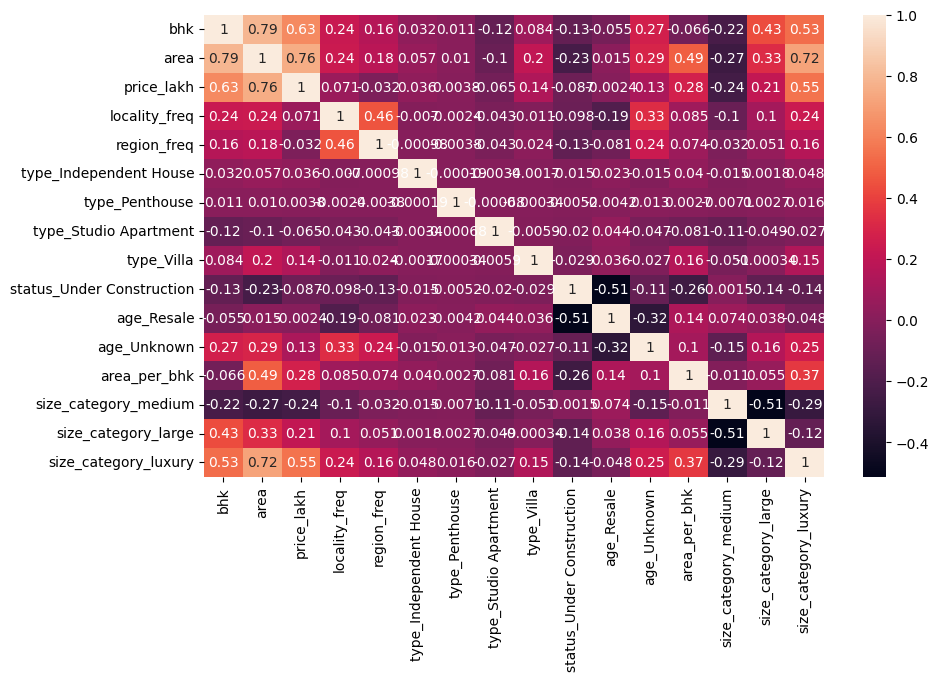

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)

In [32]:
# Removing outliers using IQR method
Q1=data['price_lakh'].quantile(0.25)
Q3=data['price_lakh'].quantile(0.75)

IQR=Q3-Q1
data=data[(data['price_lakh']>=Q1-1.5*IQR)&
          (data['price_lakh']<=Q3+1.5*IQR)]

In [33]:
X= data.drop('price_lakh',axis=1)
y=data['price_lakh']

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection  import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error,r2_score

In [35]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
pipe_lr=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])

pipe_dt=Pipeline([
    ('model',DecisionTreeRegressor(random_state=42))
])
pipe_rf=Pipeline([
    ('model',RandomForestRegressor(random_state=42))
])
pipe_xgb=Pipeline([
    ('model',XGBRegressor(random_state=42))
])

In [37]:
models={
    "Linear Regression":pipe_lr,
    "Decision Tree":pipe_dt,
    "Random Forest":pipe_rf,
    "XGBoost":pipe_xgb
}

for name,pipe in models.items():
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)

    mae=mean_absolute_error(y_test,pred)
    r2=round(r2_score(y_test,pred)*100,2)

    print(name)
    print("MAE :",mae)
    print(f"R2 Score {r2}%")
    print("-------------------")

Linear Regression
MAE : 42.8030878740523
R2 Score 54.18%
-------------------
Decision Tree
MAE : 14.30792346954485
R2 Score 85.97%
-------------------
Random Forest
MAE : 12.667699343269451
R2 Score 91.34%
-------------------
XGBoost
MAE : 16.636033888083574
R2 Score 89.99%
-------------------


In [38]:
param_grid={
    'model__n_estimators':[100,200,300],
    'model__max_depth':[None,10,20],
    'model__min_samples_split':[2,5]
}

grid=GridSearchCV(pipe_rf,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [39]:
print("Best Parameters:",grid.best_params_)
best_model=grid.best_estimator_

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [40]:
pred=best_model.predict(X_test)

mae=mean_absolute_error(y_test,pred)
r2=round(r2_score(y_test,pred)*100,2)

print("Final MAE :",mae)
print("Final R2:",r2,"%")

Final MAE : 12.629974968591311
Final R2: 91.38 %


In [41]:
pred_price=np.expm1(pred)

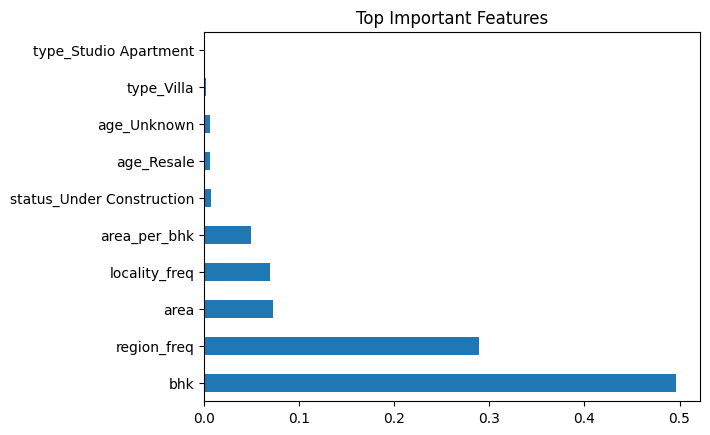

In [42]:
import matplotlib.pyplot as plt

importance = best_model.named_steps['model'].feature_importances_

feature_imp = pd.Series(importance, index=X.columns)

feature_imp.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top Important Features")

plt.show()

In [43]:
import joblib

# joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [44]:


model = joblib.load("house_price_model.pkl")

sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print(prediction)

[12.95666667]
